In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('C:\\Users\\ARUN\\Downloads\\apple_jobs.csv')

initial_rows = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {initial_rows - len(df)} duplicate rows.")
print("Missing values per column:\n", df.isnull().sum())

df['preferred_qual'] = df['preferred_qual'].fillna('Not Specified')
df['education&experience'] = df['education&experience'].fillna('Not Specified')
df['resp_length'] = df['responsibilities'].str.len()

Q1 = df['resp_length'].quantile(0.25)
Q3 = df['resp_length'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_cleaned = df[(df['resp_length'] >= lower_limit) & (df['resp_length'] <= upper_limit)]

print(f"Detected {len(df) - len(df_cleaned)} outliers in job description lengths.")
print(f"Final dataset size: {len(df_cleaned)} rows.")

df_cleaned.to_csv('cleaned_step1.csv', index=False)

Removed 112 duplicate rows.
Missing values per column:
 title                      0
location                   0
minimum_qual               0
preferred_qual          1324
responsibilities           0
education&experience      76
dtype: int64
Detected 70 outliers in job description lengths.
Final dataset size: 1966 rows.


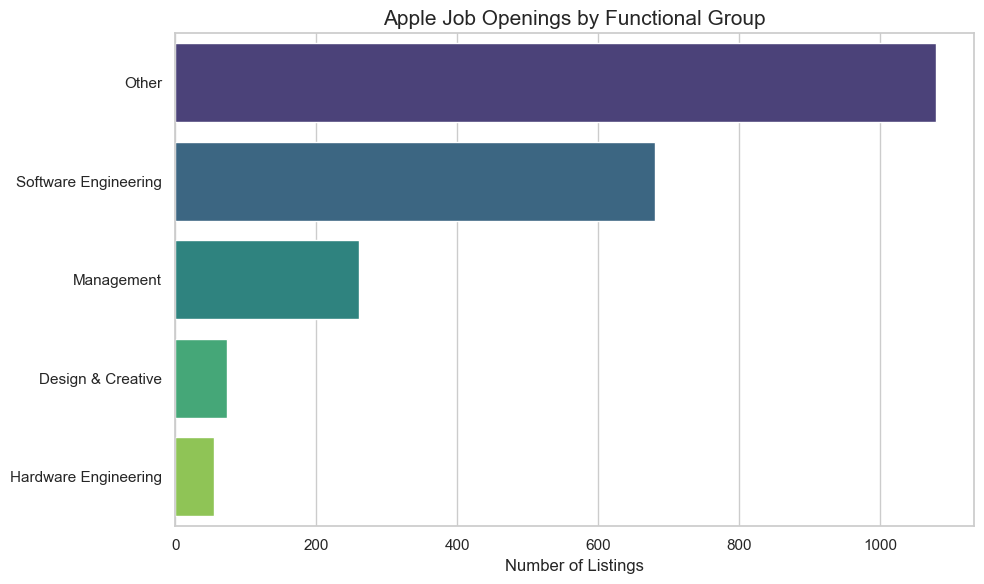

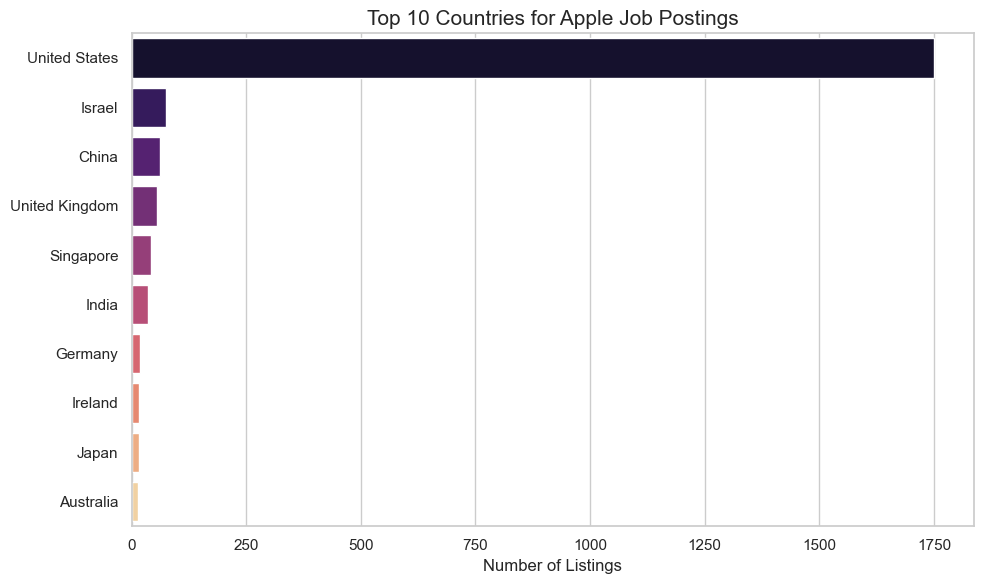

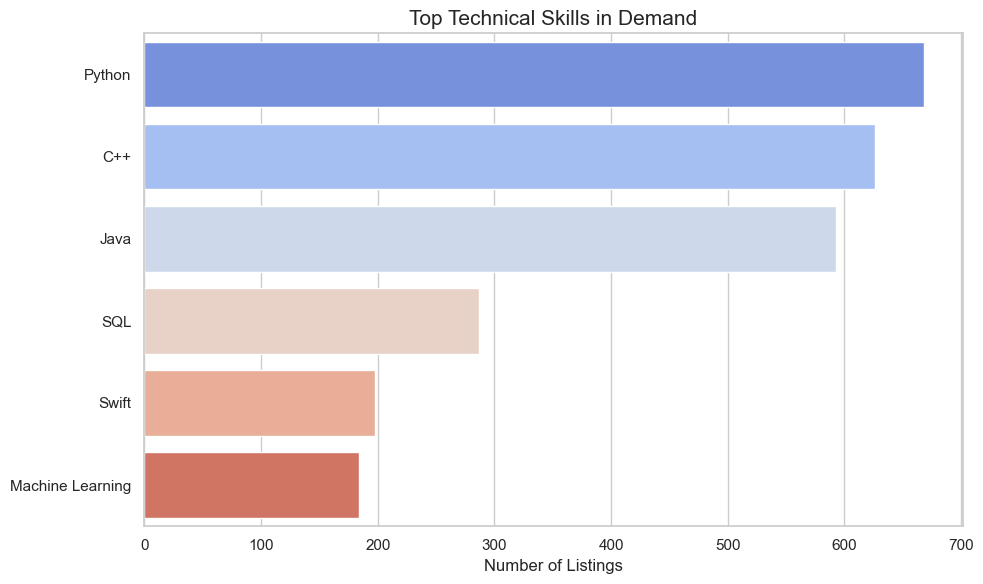

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\Users\\ARUN\\Downloads\\apple_jobs.csv')

df['preferred_qual'] = df['preferred_qual'].fillna('Not Specified')
df['education&experience'] = df['education&experience'].fillna('Not Specified')

df['country'] = df['location'].str.split(',').str[-1].str.strip()

def categorize_role(title):
    title = title.lower()
    if 'software' in title: return 'Software Engineering'
    if 'hardware' in title or 'silicon' in title: return 'Hardware Engineering'
    if 'manager' in title or 'lead' in title: return 'Management'
    if 'design' in title: return 'Design & Creative'
    return 'Other'

df['job_group'] = df['title'].apply(categorize_role)

skills = ['Python', 'Java', 'C++', 'Swift', 'SQL', 'Machine Learning']
for s in skills:
    df[s] = df['minimum_qual'].str.contains(s, case=False, na=False, regex=False).astype(int)

sns.set_theme(style="whitegrid")

def create_clean_barplot(data_series, title, filename, palette):
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=data_series.values,
        y=data_series.index,
        hue=data_series.index,
        palette=palette,
        legend=False
    )
    plt.title(title, fontsize=15)
    plt.xlabel('Number of Listings')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

create_clean_barplot(df['job_group'].value_counts(),
                     'Apple Job Openings by Functional Group',
                     'category_dist.png', 'viridis')

create_clean_barplot(df['country'].value_counts().head(10),
                     'Top 10 Countries for Apple Job Postings',
                     'top_countries.png', 'magma')

skill_demand = df[skills].sum().sort_values(ascending=False)
create_clean_barplot(skill_demand,
                     'Top Technical Skills in Demand',
                     'skill_demand.png', 'coolwarm')

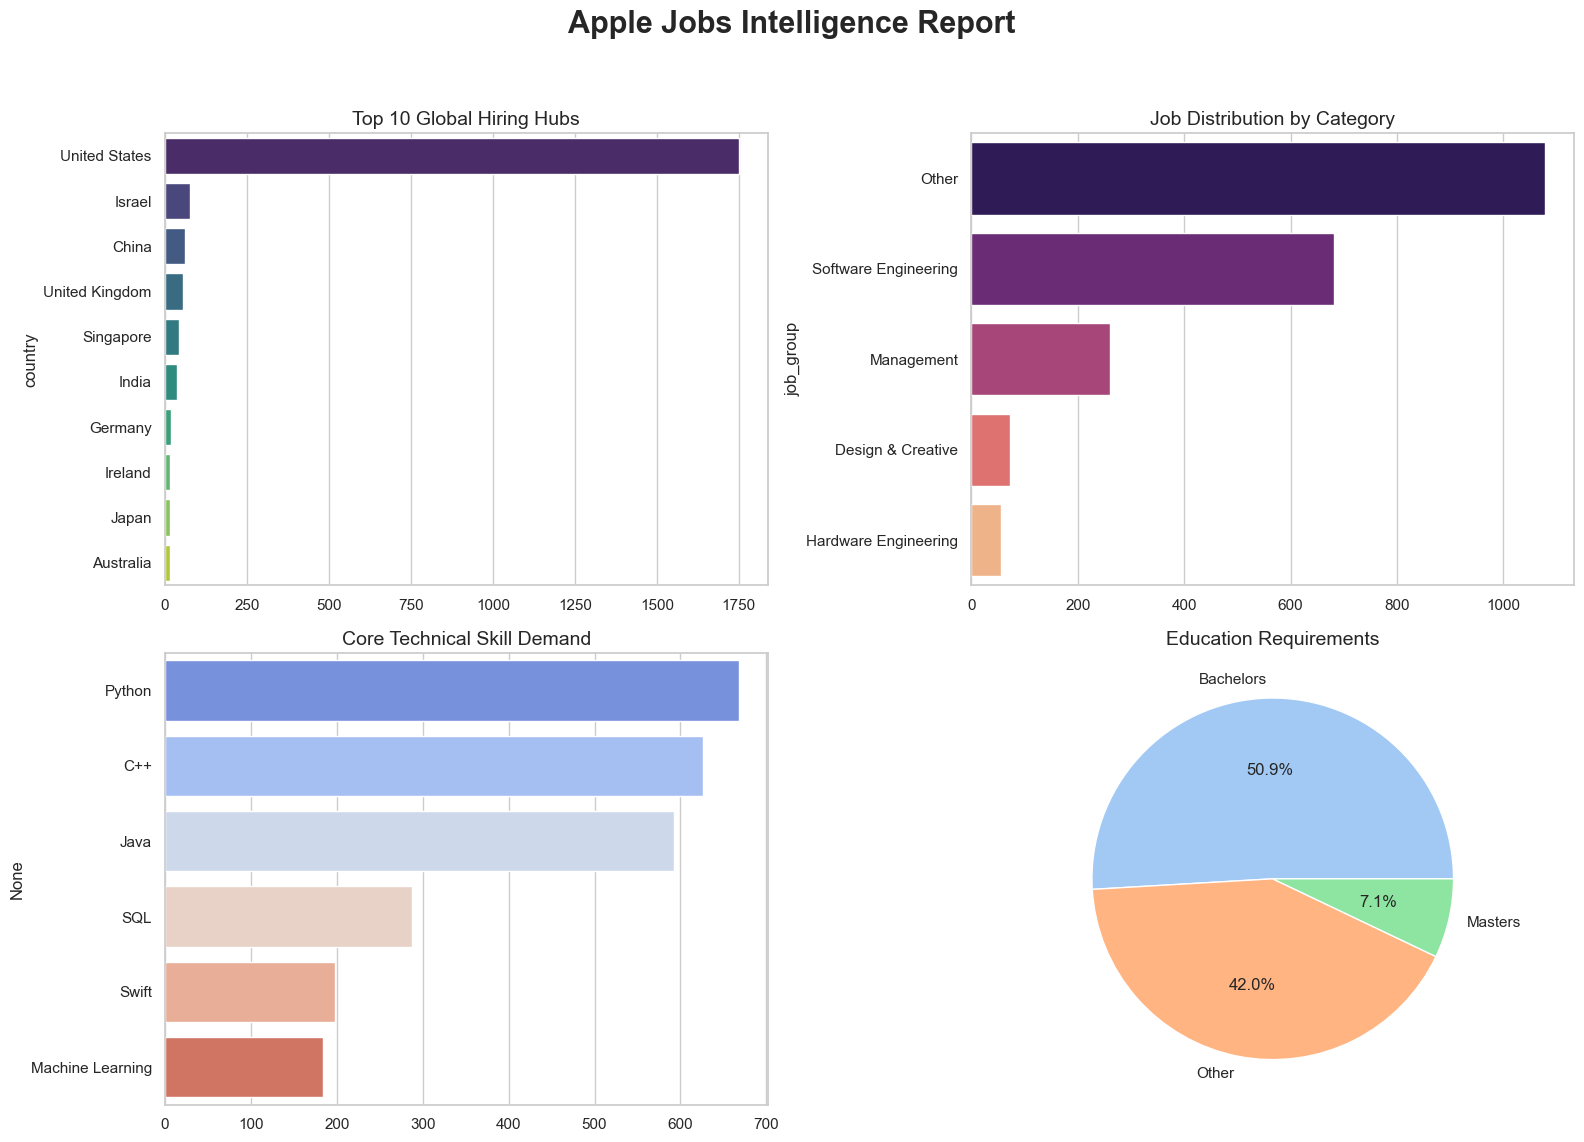

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\Users\\ARUN\\Downloads\\apple_jobs.csv')
df['preferred_qual'] = df['preferred_qual'].fillna('Not Specified')
df['education&experience'] = df['education&experience'].fillna('Not Specified')
df['country'] = df['location'].str.split(',').str[-1].str.strip()

def categorize_role(title):
    title = title.lower()
    if 'software' in title: return 'Software Engineering'
    if 'hardware' in title or 'silicon' in title: return 'Hardware Engineering'
    if 'manager' in title or 'lead' in title: return 'Management'
    if 'design' in title: return 'Design & Creative'
    return 'Other'
df['job_group'] = df['title'].apply(categorize_role)

# Extract Skills (using regex=False to handle literal 'C++')
skills = ['Python', 'Java', 'C++', 'Swift', 'SQL', 'Machine Learning']
for s in skills:
    df[s] = df['minimum_qual'].str.contains(s, case=False, na=False, regex=False).astype(int)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Apple Jobs Intelligence Report', fontsize=22, fontweight='bold')

top_countries = df['country'].value_counts().head(10)
sns.barplot(ax=axes[0, 0], x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis')
axes[0, 0].set_title('Top 10 Global Hiring Hubs', fontsize=14)
axes[0, 0].get_legend().remove() if axes[0, 0].get_legend() else None

job_groups = df['job_group'].value_counts()
sns.barplot(ax=axes[0, 1], x=job_groups.values, y=job_groups.index, hue=job_groups.index, palette='magma')
axes[0, 1].set_title('Job Distribution by Category', fontsize=14)
axes[0, 1].get_legend().remove() if axes[0, 1].get_legend() else None

skill_demand = df[skills].sum().sort_values(ascending=False)
sns.barplot(ax=axes[1, 0], x=skill_demand.values, y=skill_demand.index, hue=skill_demand.index, palette='coolwarm')
axes[1, 0].set_title('Core Technical Skill Demand', fontsize=14)
axes[1, 0].get_legend().remove() if axes[1, 0].get_legend() else None

edu_counts = df['education&experience'].apply(lambda x: 'Bachelors' if 'BS' in str(x).upper() else 'Masters' if 'MS' in str(x).upper() else 'Other').value_counts()
axes[1, 1].pie(edu_counts, labels=edu_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Education Requirements', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('apple_report.png')